In [32]:
import pandas as pd 
import numpy as np 
import os 

In [4]:
warehouse = pd.read_csv('warehouse.csv')
warehouse_1A = pd.read_csv('warehouse_1A.csv')

In [ ]:
print(warehouse['type'].unique())
print(warehouse_1A['type'].unique())

['Kho dự án' 'Đường trục' 'Kho Bưu cục' 'Kho tổng kết nối' 'Trung chuyển'
 'Chưa biết']
['Trung chuyển' 'Kho Bưu cục' 'Kho tổng kết nối' 'Đường trục']


In [36]:
list1A = warehouse_1A['name']
buu_cuc = warehouse[(warehouse['type'] == 'Kho Bưu cục') & (~warehouse['name'].isin(list1A))]
not_buu_cuc = warehouse[(warehouse['type'] == 'Kho Bưu cục') & (warehouse['name'].isin(list1A))]

print(buu_cuc)
print(not_buu_cuc)


                               name         type province_name
3                       Kho Bến Cát  Kho Bưu cục    Bình Dương
6             Kho Bưu cục Thanh Sơn  Kho Bưu cục    Ninh Thuận
7            Kho Bưu cục Long Thành  Kho Bưu cục      Đồng Nai
9                  Bưu cục Phúc Thọ  Kho Bưu cục    TP. Hà Nội
10                   Kho Thạch Thất  Kho Bưu cục    TP. Hà Nội
..                              ...          ...           ...
479           Kho Bưu cục Trảng Bom  Kho Bưu cục           NaN
480            Kho Bưu Cục Phú Giáo  Kho Bưu cục           NaN
483           Kho Bưu cục Tràm Chim  Kho Bưu cục           NaN
484             Kho Bưu cục Chợ Mới  Kho Bưu cục           NaN
487  Bưu cục Dự Án Vgreen Hải Phòng  Kho Bưu cục           NaN

[331 rows x 3 columns]
                       name         type province_name
199        Kho Hàng Gia Lai  Kho Bưu cục       Gia Lai
308  Kho hàng Buôn Ma Thuột  Kho Bưu cục       Đắk Lắk
357          Bưu cục Hà Nam  Kho Bưu cục        Hà Nam


In [34]:
route_distribution = pd.read_csv('output_routes/route_distribution.csv')
print(route_distribution.shape)
rfbc = route_distribution[(route_distribution['first_trunk'].isin(buu_cuc['name'])) &( route_distribution['last_trunk'].isin(buu_cuc['name']))].copy()
rfbc.to_csv(os.path.join('output_routes', 'route_buu_cuc.csv'), index = False)

(119572, 12)


In [50]:
def pair_stats(grp):
    df    = grp.copy()
    rank1 = df[df["rank_trong_cap"] == 1].copy()

    ps = rank1[[
        "first_trunk", "last_trunk",
        "first_trunk_prov", "last_trunk_prov",  
        "so_route_theo_cap",
        "pct_bill_theo_cap", "pct_weight_theo_cap",
        "trunk_route", "n_stops",
    ]].rename(columns={
        "pct_bill_theo_cap":   "pct_route_chinh_bill",
        "pct_weight_theo_cap": "pct_route_chinh_kg",
        "trunk_route":         "route_chinh",
        "n_stops":             "so_tram_route_chinh",
    })

    pair_bill_total = df.groupby(["first_trunk", "last_trunk"])["so_bill"].sum().rename("tong_bill")
    pair_kg_total   = df.groupby(["first_trunk", "last_trunk"])["tong_kg"].sum().rename("tong_kg")
    ps = ps.merge(pair_bill_total, on=["first_trunk", "last_trunk"])
    ps = ps.merge(pair_kg_total,   on=["first_trunk", "last_trunk"])
    ps["tong_kg"] = ps["tong_kg"].round(1)
    ps = ps.sort_values("tong_bill", ascending=False).reset_index(drop=True)

    bins_pct   = [0, 50, 70, 90, 95, 100.001]
    labels_pct = ["<50%", "50-70%", "70-90%", "90-95%", ">95%"]
    ps["nhom_co_dinh"] = pd.cut(
        ps["pct_route_chinh_bill"], bins=bins_pct, labels=labels_pct, right=False
    )

    bins_n   = [1, 2, 3, 4, 6, 11, 9999]
    labels_n = ["1 route", "2 routes", "3 routes", "4-5 routes", "6-10 routes", ">10 routes"]
    ps["nhom_so_route"] = pd.cut(
        ps["so_route_theo_cap"], bins=bins_n, labels=labels_n, right=False
    )
    
    ps.to_csv(os.path.join('output_routes', "pair_buu_cuc.csv"), index=False)
    print(f"  OK: pair_stats.csv  ({len(ps):,} cap)")
    return ps

pair_stats(rfbc)

  OK: pair_stats.csv  (15,907 cap)


,first_trunk,last_trunk,first_trunk_prov,last_trunk_prov,so_route_theo_cap,pct_route_chinh_bill,pct_route_chinh_kg,route_chinh,so_tram_route_chinh,tong_bill,tong_kg,nhom_co_dinh,nhom_so_route
0,Bưu Cục Thanh Xuân,Bưu Cục Thanh Xuân,TP. Hà Nội,TP. Hà Nội,173,40.47,10.37,Bưu Cục Thanh Xuân → Kho Thư Nội Bộ - VP1 → Bư...,3,6813,13466.0,<50%,>10 routes
1,Kho dự án Bắc Ninh,Bưu Cục Hoàng Mai,Bắc Ninh,TP. Hà Nội,30,93.49,91.92,Kho dự án Bắc Ninh → Kho Văn Giang → Bưu Cục H...,3,2886,19273.1,90-95%,>10 routes
2,Kho dự án Bắc Ninh,Bưu Cục Cầu Giấy,Bắc Ninh,TP. Hà Nội,41,93.84,93.04,Kho dự án Bắc Ninh → Kho Văn Giang → Bưu Cục C...,3,2777,17681.6,90-95%,>10 routes
3,Kho dự án Bắc Ninh,Kho hàng Vĩnh Phúc,Bắc Ninh,Vĩnh Phúc,13,94.73,94.29,Kho dự án Bắc Ninh → Kho Văn Giang → Kho hàng ...,3,2562,15338.9,90-95%,>10 routes
4,Kho dự án Bắc Ninh,Bưu Cục An Hưng,Bắc Ninh,TP. Hà Nội,23,93.86,92.95,Kho dự án Bắc Ninh → Kho Văn Giang → Bưu Cục A...,3,2492,18647.1,90-95%,>10 routes
...,...,...,...,...,...,...,...,...,...,...,...,...,...
15902,Điểm nhận hàng hoá Nghĩa Lộ Yên Bái,Kho Ninh Bình,Yên Bái,Ninh Bình,1,100.00,100.00,Điểm nhận hàng hoá Nghĩa Lộ Yên Bái → Kho Yên ...,4,1,6.6,>95%,1 route
15903,Điểm nhận hàng hoá Nghĩa Lộ Yên Bái,Kho Phú Quốc,Yên Bái,Kiên Giang,1,100.00,100.00,Điểm nhận hàng hoá Nghĩa Lộ Yên Bái → Kho Yên ...,7,1,2.3,>95%,1 route
15904,Điểm nhận hàng hoá Nghĩa Lộ Yên Bái,Kho TGDĐ Nguyễn Trãi,Yên Bái,TP. Hồ Chí Minh,1,100.00,100.00,Điểm nhận hàng hoá Nghĩa Lộ Yên Bái → Kho Yên ...,5,1,0.2,>95%,1 route
15905,Điểm nhận hàng hoá Nghĩa Lộ Yên Bái,Kho Tĩnh Gia,Yên Bái,Thanh Hóa,1,100.00,100.00,Điểm nhận hàng hoá Nghĩa Lộ Yên Bái → Kho Yên ...,5,1,5.3,>95%,1 route


In [49]:
route_buu_unique = rfbc[rfbc['first_trunk'] != rfbc['last_trunk']]
pair_unique = pair_stats(route_buu_unique) 
route_buu_unique.to_csv(os.path.join("output_routes",'route_buu_unique.csv')) 
pair_unique.to_csv(os.path.join('output_routes', 'pair_unique.csv')) 

  OK: pair_stats.csv  (15,753 cap)


In [55]:
ps = pd.read_csv('output_routes/pair_buu_cuc.csv')
ps_unique = pd.read_csv('output_routes/pair_unique.csv')

In [56]:
chaotic_pairs = (
    ps[ps["tong_bill"] >= 100]
    .sort_values("pct_route_chinh_bill")
    .head(50)
    .sort_values(["tong_bill"], ascending=[False])
    [["first_trunk","last_trunk","pct_route_chinh_bill",
               "so_route_theo_cap","tong_bill","route_chinh"]]
    .rename(columns={"first_trunk":"from","last_trunk":"to",
                     "pct_route_chinh_bill":"pct","so_route_theo_cap":"n_routes",
                     "tong_bill":"bills","route_chinh":"top_route"})
    .to_dict("records")
)

chaotic_pairs_unique = (
    ps_unique[ps_unique["tong_bill"] >= 100]
    .sort_values("pct_route_chinh_bill")
    .head(50)
    .sort_values(["tong_bill"], ascending=[False])
    [["first_trunk","last_trunk","pct_route_chinh_bill",
               "so_route_theo_cap","tong_bill","route_chinh"]]
    .rename(columns={"first_trunk":"from","last_trunk":"to",
                     "pct_route_chinh_bill":"pct","so_route_theo_cap":"n_routes",
                     "tong_bill":"bills","route_chinh":"top_route"})
    .to_dict("records")
)

C:\Users\VIET ANH\AppData\Local\Temp\ipykernel_21316\3251685182.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='bills', y='pair_name', data=df_plot, palette='viridis')
C:\Users\VIET ANH\AppData\Local\Temp\ipykernel_21316\3251685182.py:35: UserWarning: Glyph 10132 (\N{HEAVY WIDE-HEADED RIGHTWARDS ARROW}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\VIET ANH\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10132 (\N{HEAVY WIDE-HEADED RIGHTWARDS ARROW}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


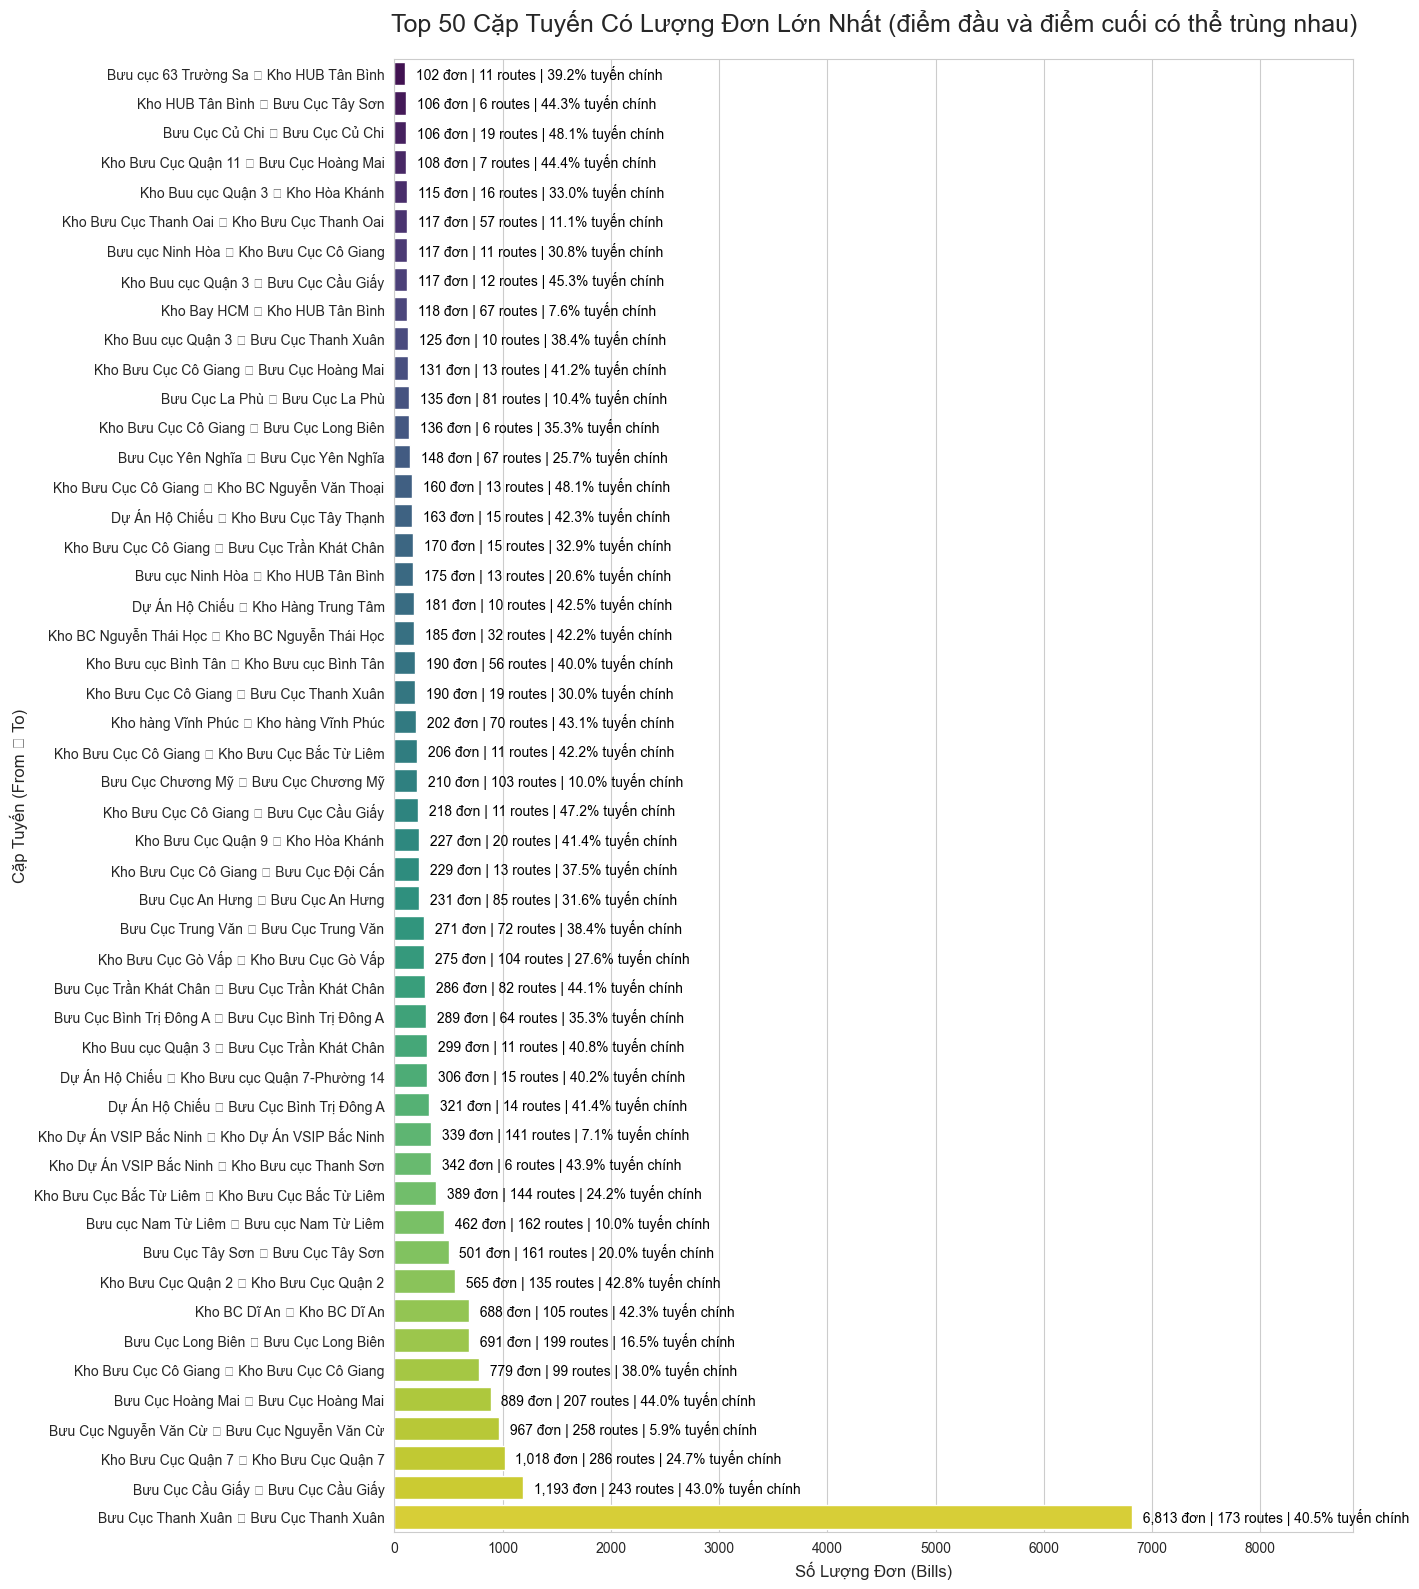

In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_plot = pd.DataFrame(chaotic_pairs)

df_plot['pair_name'] = df_plot['from'] + ' ➔ ' + df_plot['to']

df_plot = df_plot.sort_values('bills', ascending=True)

plt.figure(figsize=(14, 16))
sns.set_style("whitegrid")

ax = sns.barplot(x='bills', y='pair_name', data=df_plot, palette='viridis')

plt.title('Top 50 Cặp Tuyến Có Lượng Đơn Lớn Nhất (điểm đầu và điểm cuối có thể trùng nhau)', fontsize=18, pad=20)
plt.xlabel('Số Lượng Đơn (Bills)', fontsize=12)
plt.ylabel('Cặp Tuyến (From ➔ To)', fontsize=12)

for i, p in enumerate(ax.patches):
    row = df_plot.iloc[i]
    bills = row['bills']
    n_routes = row['n_routes']
    pct = row['pct'] 
    text = f" {int(bills):,} đơn | {int(n_routes)} routes | {pct:.1f}% tuyến chính"
    ax.annotate(text, 
                (p.get_width(), p.get_y() + p.get_height() / 2.), 
                ha='left', va='center', 
                xytext=(5, 0), textcoords='offset points',
                fontsize=10, color='black')

max_bills = df_plot['bills'].max()
plt.xlim(0, max_bills * 1.3)

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_plot = pd.DataFrame(chaotic_pairs_unique)

df_plot['pair_name'] = df_plot['from'] + ' ➔ ' + df_plot['to']

df_plot = df_plot.sort_values('bills', ascending=True)

plt.figure(figsize=(14, 16))
sns.set_style("whitegrid")

ax = sns.barplot(x='bills', y='pair_name', data=df_plot, palette='viridis')

plt.title('Top 50 Cặp Tuyến Có Lượng Đơn Lớn Nhất (điểm đầu và điểm cuối KHÔNG THỂ trùng nhau)', fontsize=18, pad=20)
plt.xlabel('Số Lượng Đơn (Bills)', fontsize=12)
plt.ylabel('Cặp Tuyến (From ➔ To)', fontsize=12)

for i, p in enumerate(ax.patches):
    row = df_plot.iloc[i]
    bills = row['bills']
    n_routes = row['n_routes']
    pct = row['pct'] 
    text = f" {int(bills):,} đơn | {int(n_routes)} routes | {pct:.1f}% tuyến chính"
    ax.annotate(text, 
                (p.get_width(), p.get_y() + p.get_height() / 2.), 
                ha='left', va='center', 
                xytext=(5, 0), textcoords='offset points',
                fontsize=10, color='black')

max_bills = df_plot['bills'].max()
plt.xlim(0, max_bills * 1.3)

plt.tight_layout()
plt.show()
